In [2]:
#importar paquetes
#GUARDAR
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# =========================
# BLOQUE 0: Carga excel
# =========================
file_path = "LCGO a OSBL - Históricos 2024 2025.xlsx"

df = pd.read_excel(file_path, sheet_name="Data - LCGO")

In [4]:
# =========================
# BLOQUE 1: Separar 2024 y 2025
# =========================
df_2024 = df.iloc[:, 0:4].copy()
df_2025 = df.iloc[:, 4:8].copy()

df_2024.columns = ["Fecha", "Flujo_U108", "Flujo_U109", "Flujo_Tanques"]
df_2025.columns = ["Fecha", "Flujo_U108", "Flujo_U109", "Flujo_Tanques"]

# Convertir fechas
df_2024["Fecha"] = pd.to_datetime(df_2024["Fecha"], format="%d-%b-%y %H:%M:%S", errors="coerce")
df_2025["Fecha"] = pd.to_datetime(df_2025["Fecha"], format="%d-%b-%y %H:%M:%S", errors="coerce")

In [5]:
# =========================
# BLOQUE 2: Merge vertical
# =========================
df_merged = pd.concat([df_2024, df_2025], axis=0)

df_merged = (
    df_merged
    .dropna(subset=["Fecha"])
    .sort_values("Fecha")
    .drop_duplicates(subset="Fecha")
    .set_index("Fecha")
)

In [6]:
df_merged.head()

,Flujo_U108,Flujo_U109,Flujo_Tanques
Fecha,,,
2024-01-01 00:00:00,1002.919261,9019.886294,[-11059] No Good Data For Calculation
2024-01-01 00:01:00,1003.169285,9022.277377,[-11059] No Good Data For Calculation
2024-01-01 00:02:00,1003.41931,9024.66846,[-11059] No Good Data For Calculation
2024-01-01 00:03:00,1003.669334,9027.059543,[-11059] No Good Data For Calculation
2024-01-01 00:04:00,1003.919358,9029.450626,[-11059] No Good Data For Calculation


In [7]:
# =========================
# BLOQUE 3: Suma con indentación de NaN
# =========================

# Convertir a numérico textos como "No Good Data For Calculation" = NaN
#columna auxiliar para Flujo_U108
df_merged["Flujo_U108_num"] = pd.to_numeric(df_merged["Flujo_U108"], errors="coerce")
#columna auxiliar para Flujo_U109
df_merged["Flujo_U109_num"] = pd.to_numeric(df_merged["Flujo_U109"], errors="coerce")
#columna auxiliar para Flujo_Tanques
df_merged["Flujo_Tanques_num"] = pd.to_numeric(df_merged["Flujo_Tanques"], errors="coerce")

# Identificar entradas problemáticas:
# 1) No numéricas (NaN)
# 2) Negativos
mask_problem = (
    df_merged["Flujo_U108_num"].isna() |
    df_merged["Flujo_U109_num"].isna() |
    df_merged["Flujo_Tanques_num"].isna() |
    (df_merged["Flujo_U108_num"] < 0) |
    (df_merged["Flujo_U109_num"] < 0) |
    (df_merged["Flujo_Tanques_num"] < 0)
)

# Crear columna suma condicional:
df_merged["Flujo_Total_LCGO"] = (
    df_merged["Flujo_U108_num"] + df_merged["Flujo_U109_num"] + df_merged["Flujo_Tanques_num"]
)

# Indentar resultado de suma por NaN (entradas problemáticas)
df_merged.loc[mask_problem, "Flujo_Total_LCGO"] = np.nan

In [8]:
# =========================
# BLOQUE 4: Preparar datos para graficar
# =========================
import numpy as np
import matplotlib.pyplot as plt

# Convertir a numérico y forzar negativos a NaN
for col in ["Flujo_U108", "Flujo_U109", "Flujo_Tanques", "Flujo_Total_LCGO"]:
    df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")
    df_merged.loc[df_merged[col] < 0, col] = np.nan

In [9]:
# =========================
# BLOQUE 5.0: Mediana por columna (vector independiente)
# =========================

# Asegurar numérico y negativos como NaN
df_merged["Flujo_U108"] = pd.to_numeric(df_merged["Flujo_U108"], errors="coerce")
df_merged["Flujo_U109"] = pd.to_numeric(df_merged["Flujo_U109"], errors="coerce")
df_merged["Flujo_Tanques"] = pd.to_numeric(df_merged["Flujo_Tanques"], errors="coerce")
df_merged["Flujo_Total_LCGO"] = pd.to_numeric(df_merged["Flujo_Total_LCGO"], errors="coerce")

df_merged.loc[df_merged["Flujo_U108"] < 0, "Flujo_U108"] = np.nan
df_merged.loc[df_merged["Flujo_U109"] < 0, "Flujo_U109"] = np.nan
df_merged.loc[df_merged["Flujo_Tanques"] < 0, "Flujo_Tanques"] = np.nan
df_merged.loc[df_merged["Flujo_Total_LCGO"] < 0, "Flujo_Total_LCGO"] = np.nan

# Medianas individuales
mediana_U108 = df_merged["Flujo_U108"].median(skipna=True)
mediana_U109 = df_merged["Flujo_U109"].median(skipna=True)
mediana_Tanques = df_merged["Flujo_Tanques"].median(skipna=True)
mediana_Total = df_merged["Flujo_Total_LCGO"].median(skipna=True)

print("Mediana Flujo_U108:", mediana_U108)
print("Mediana Flujo_U109:", mediana_U109)
print("Mediana Flujo_Tanques:", mediana_Tanques)
print("Mediana Flujo_Total_LCGO:", mediana_Total)

Mediana Flujo_U108: 3012.2119552248855
Mediana Flujo_U109: 5020.408408033066
Mediana Flujo_Tanques: 3356.1935438368055
Mediana Flujo_Total_LCGO: 11390.284689812266


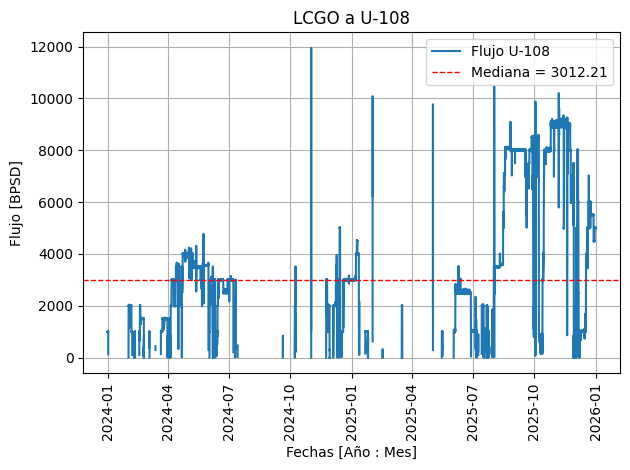

In [19]:
# =========================
# BLOQUE 5.1: Gráfico discontinuo Flujo U108
# =========================
#plt.figure(figsize=(14,6))

plt.plot(df_merged.index, df_merged["Flujo_U108"], label="Flujo U-108")

plt.axhline(mediana_U108, linestyle="--", linewidth=1, color='r',
            label=f"Mediana = {mediana_U108:.2f}")

plt.xlabel("Fechas [Año : Mes]")
plt.ylabel("Flujo [BPSD]")
plt.xticks(rotation=90)
plt.title("LCGO a U-108")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

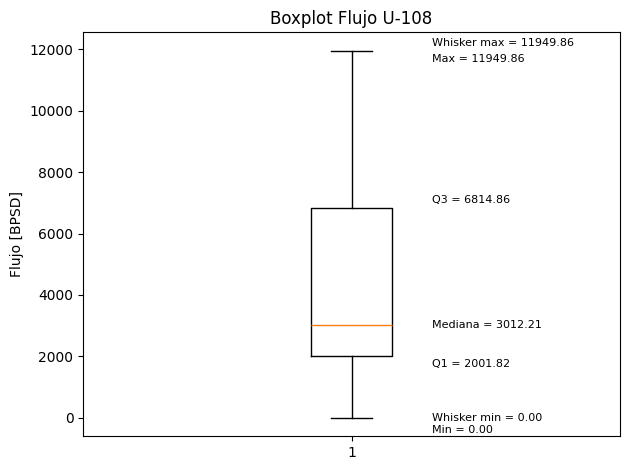

In [22]:
data_U108 = df_merged["Flujo_U108"].dropna()

box = plt.boxplot(data_U108, showfliers=True)

ymin, ymax = plt.ylim()
offset = (ymax - ymin) * 0.02

q1 = data_U108.quantile(0.25)
q3 = data_U108.quantile(0.75)

whiskers = box['whiskers']
low_whisker = whiskers[0].get_ydata()[1] # extremo inferior
high_whisker = whiskers[1].get_ydata()[1] # extremo superior

min_val = data_U108.min()
max_val = data_U108.max()

plt.text(1.15, mediana_U108,
         f"Mediana = {mediana_U108:.2f}",
         verticalalignment='center', fontsize=8)

plt.text(1.15, q1 - offset, f"Q1 = {q1:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, q3 + offset, f"Q3 = {q3:.2f}", verticalalignment='center', fontsize=8)

plt.text(1.15, low_whisker, f"Whisker min = {low_whisker:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, high_whisker + offset, f"Whisker max = {high_whisker:.2f}", verticalalignment='center', fontsize=8)

plt.text(1.15, min_val - 1.5*offset, f"Min = {min_val:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, max_val - offset, f"Max = {max_val:.2f}", verticalalignment='center', fontsize=8)

plt.ylabel("Flujo [BPSD]")
plt.title("Boxplot Flujo U-108")
plt.tight_layout()
plt.show()

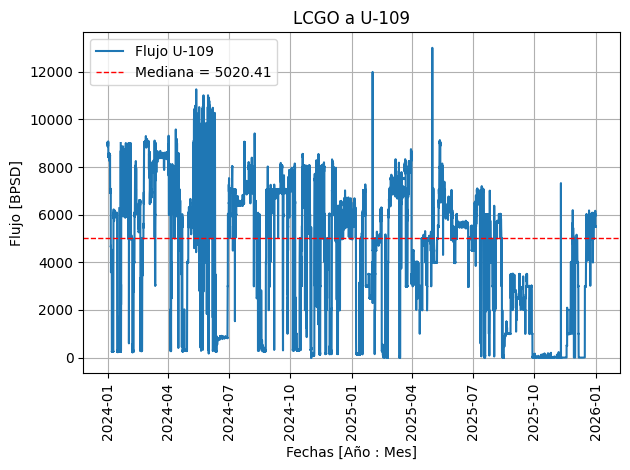

In [23]:
# =========================
# BLOQUE 5.1: Gráfico discontinuo Flujo U109
# =========================
#plt.figure(figsize=(14,6))

plt.plot(df_merged.index, df_merged["Flujo_U109"], label="Flujo U-109")

plt.axhline(mediana_U109, linestyle="--", linewidth=1, color='r',
            label=f"Mediana = {mediana_U109:.2f}")

plt.xlabel("Fechas [Año : Mes]")
plt.ylabel("Flujo [BPSD]")
plt.xticks(rotation=90)
plt.title("LCGO a U-109")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

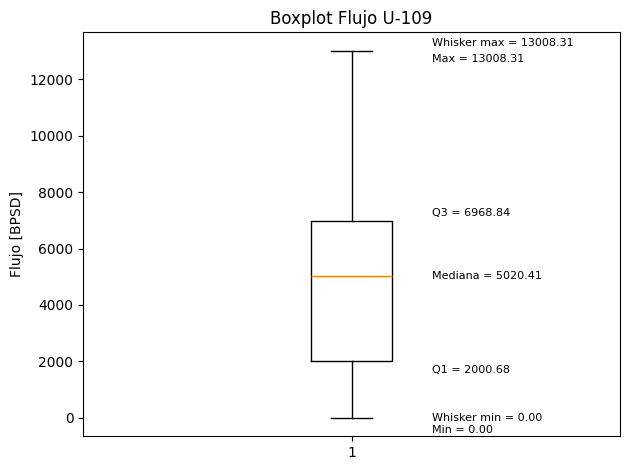

In [25]:
data_U109 = df_merged["Flujo_U109"].dropna()

box = plt.boxplot(data_U109, showfliers=True)

ymin, ymax = plt.ylim()
offset = (ymax - ymin) * 0.02

q1 = data_U109.quantile(0.25)
q3 = data_U109.quantile(0.75)

whiskers = box['whiskers']
low_whisker = whiskers[0].get_ydata()[1] # extremo inferior
high_whisker = whiskers[1].get_ydata()[1] # extremo superior

min_val = data_U109.min()
max_val = data_U109.max()

plt.text(1.15, mediana_U109,
         f"Mediana = {mediana_U109:.2f}",
         verticalalignment='center', fontsize=8)

plt.text(1.15, q1 - offset, f"Q1 = {q1:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, q3 + offset, f"Q3 = {q3:.2f}", verticalalignment='center', fontsize=8)

plt.text(1.15, low_whisker, f"Whisker min = {low_whisker:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, high_whisker + offset, f"Whisker max = {high_whisker:.2f}", verticalalignment='center', fontsize=8)

plt.text(1.15, min_val - 1.5*offset, f"Min = {min_val:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, max_val - offset, f"Max = {max_val:.2f}", verticalalignment='center', fontsize=8)

plt.ylabel("Flujo [BPSD]")
plt.title("Boxplot Flujo U-109")
plt.tight_layout()
plt.show()

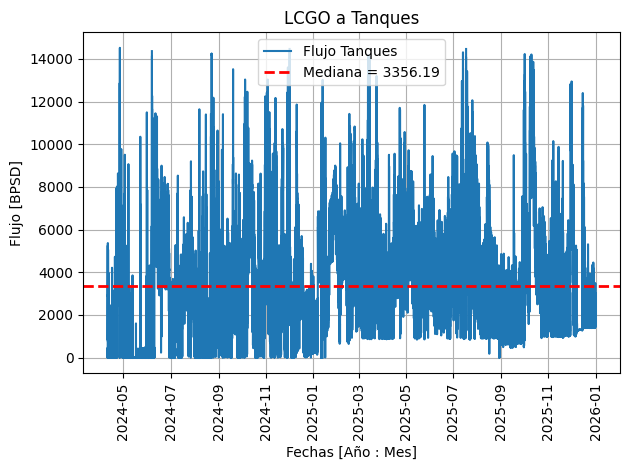

In [26]:
# =========================
# BLOQUE 5.2: Gráfico discontinuo Flujo Tanques
# =========================
#plt.figure(figsize=(14,6))

plt.plot(df_merged.index, df_merged["Flujo_Tanques"], label="Flujo Tanques")

plt.axhline(mediana_Tanques, linestyle="--", linewidth=2, color='r',
            label=f"Mediana = {mediana_Tanques:.2f}")

plt.xlabel("Fechas [Año : Mes]")
plt.ylabel("Flujo [BPSD]")
plt.xticks(rotation=90)
plt.title("LCGO a Tanques")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

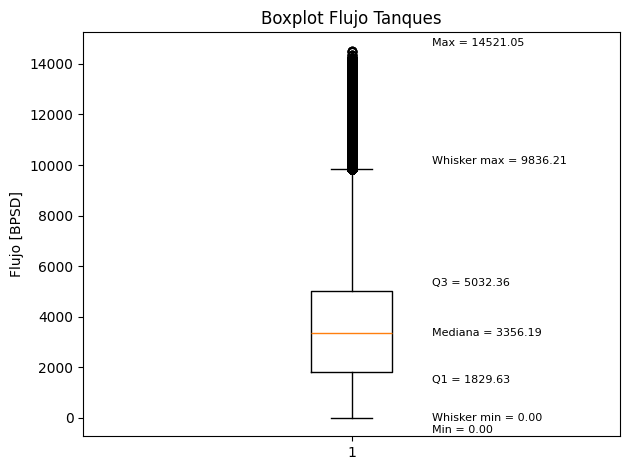

In [27]:
data_Tanques = df_merged["Flujo_Tanques"].dropna()

box = plt.boxplot(data_Tanques, showfliers=True)

ymin, ymax = plt.ylim()
offset = (ymax - ymin) * 0.02

q1 = data_Tanques.quantile(0.25)
q3 = data_Tanques.quantile(0.75)

whiskers = box['whiskers']
low_whisker = whiskers[0].get_ydata()[1] # extremo inferior
high_whisker = whiskers[1].get_ydata()[1] # extremo superior

min_val = data_Tanques.min()
max_val = data_Tanques.max()

plt.text(1.15, mediana_Tanques,
         f"Mediana = {mediana_Tanques:.2f}",
         verticalalignment='center', fontsize=8)

plt.text(1.15, q1 - offset, f"Q1 = {q1:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, q3 + offset, f"Q3 = {q3:.2f}", verticalalignment='center', fontsize=8)

plt.text(1.15, low_whisker, f"Whisker min = {low_whisker:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, high_whisker + offset, f"Whisker max = {high_whisker:.2f}", verticalalignment='center', fontsize=8)

plt.text(1.15, min_val - 1.5*offset, f"Min = {min_val:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, max_val + offset, f"Max = {max_val:.2f}", verticalalignment='center', fontsize=8)

plt.ylabel("Flujo [BPSD]")
plt.title("Boxplot Flujo Tanques")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


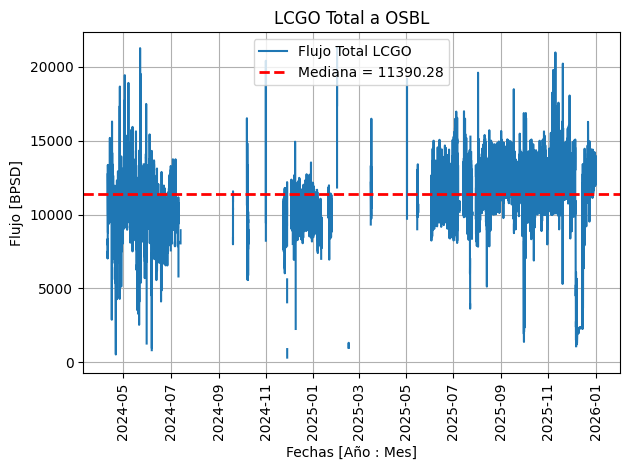

In [28]:
# =========================
# BLOQUE 5.2: Gráfico discontinuo Flujo Total_HCGO
# =========================
#plt.figure(figsize=(14,6))

plt.plot(df_merged.index, df_merged["Flujo_Total_LCGO"], label="Flujo Total LCGO")

plt.axhline(mediana_Total, linestyle="--", linewidth=2, color='r',
            label=f"Mediana = {mediana_Total:.2f}")

plt.xlabel("Fechas [Año : Mes]")
plt.ylabel("Flujo [BPSD]")
plt.xticks(rotation=90)
plt.title("LCGO Total a OSBL")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

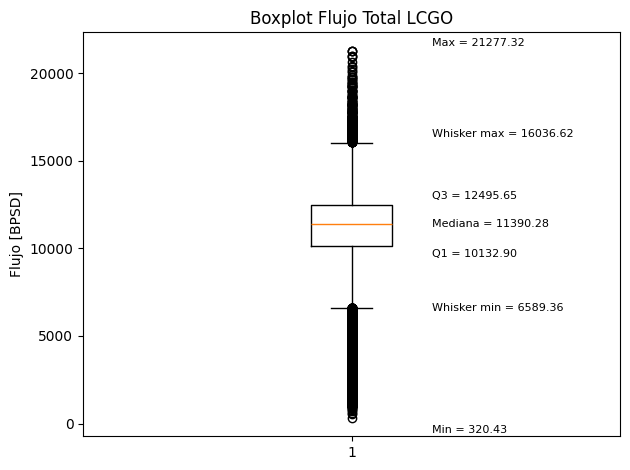

In [29]:
data_Total_LCGO = df_merged["Flujo_Total_LCGO"].dropna()

box = plt.boxplot(data_Total_LCGO, showfliers=True)

ymin, ymax = plt.ylim()
offset = (ymax - ymin) * 0.02

q1 = data_Total_LCGO.quantile(0.25)
q3 = data_Total_LCGO.quantile(0.75)

whiskers = box['whiskers']
low_whisker = whiskers[0].get_ydata()[1] # extremo inferior
high_whisker = whiskers[1].get_ydata()[1] # extremo superior

min_val = data_Total_LCGO.min()
max_val = data_Total_LCGO.max()

plt.text(1.15, mediana_Total,
         f"Mediana = {mediana_Total:.2f}",
         verticalalignment='center', fontsize=8)

plt.text(1.15, q1 - offset, f"Q1 = {q1:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, q3 + offset, f"Q3 = {q3:.2f}", verticalalignment='center', fontsize=8)

plt.text(1.15, low_whisker, f"Whisker min = {low_whisker:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, high_whisker + offset, f"Whisker max = {high_whisker:.2f}", verticalalignment='center', fontsize=8)

plt.text(1.15, min_val - 1.5*offset, f"Min = {min_val:.2f}", verticalalignment='center', fontsize=8)
plt.text(1.15, max_val + offset, f"Max = {max_val:.2f}", verticalalignment='center', fontsize=8)

plt.ylabel("Flujo [BPSD]")
plt.title("Boxplot Flujo Total LCGO")
plt.tight_layout()
plt.show()

In [18]:
columnas = ["Flujo_U108", "Flujo_U109", "Flujo_Tanques", "Flujo_Total_LCGO"]

# Asegurar formato numérico y negativos como NaN
for col in columnas:
    df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")
    df_merged.loc[df_merged[col] < 0, col] = np.nan

# Crear columna año desde el índice temporal
df_merged["Año"] = df_merged.index.year

# Calcular medianas por año
medianas_por_año = df_merged.groupby("Año")[columnas].median()

print("Medianas por año:")
print(medianas_por_año)

Medianas por año:
       Flujo_U108   Flujo_U109  Flujo_Tanques  Flujo_Total_LCGO
Año                                                            
2024  2996.926310  6456.565917    2613.923804      10281.205493
2025  5000.108216  4001.925395    3897.985649      11977.646993
